# Conventional design campaign — scaffold vs design vs target peaks

Visualize, for each of the 24 scaffold→target pairs, where the **scaffold** and **target** sit in
`(excitation, emission)` space and where the **guided designs** land, as **predicted by the
surrogate** (ESM-2 `cnn-max-d1`, all-data).

- **scaffold (measured)** and **target (measured)** — the real FPBase `(ex, em)` peaks.
- **design (surrogate)** — the surrogate's predicted `(ex, em)` for each of the 6 designed sequences
  per pair (final iteration), with the per-trial trajectory (rounds 0→3) drawn faintly.

> **No oracle for this task.** The design predictions come from the same surrogate that guided the
> search, so they are *in-sample / optimistic*, not independent validation. The scaffold and target
> markers are measured values; only the design markers are model predictions.

Data source: `guided_design/designs/design_*.csv` (produced by `guided_design/design_campaign.py`).

In [ ]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_designs(designs_dir):
    fs = sorted(glob.glob(str(Path(designs_dir) / "design_*.csv")))
    d = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    return d


def best_per_trial(d):
    """One row per (pair, trial): the ITERATION ROUND (>=1) with the smallest surrogate peak_err.
    Round 0 is the untouched scaffold and is EXCLUDED, so a 'best design' is always an actual edited
    sequence (never the original scaffold), even if every design is worse than the scaffold."""
    dd = d[d["round"] >= 1]
    idx = dd.groupby(["pair", "trial"])["peak_err"].idxmin()
    return dd.loc[idx].reset_index(drop=True)


def pair_summary(d):
    """Per pair: scaffold error (round 0) and mean/best over each trial's BEST round."""
    bt = best_per_trial(d)
    out = []
    for p, g in d.groupby("pair"):
        b = bt.loc[bt["pair"] == p, "peak_err"]
        out.append(dict(pair=p, scaffold_err=g.loc[g["round"] == 0, "peak_err"].iloc[0],
                        mean_design=b.mean(), best_design=b.min()))
    return pd.DataFrame(out).sort_values("best_design").reset_index(drop=True)


# locate guided_design/designs whether the notebook runs from the campaign root or the repo root
_cands = [Path("guided_design/designs"),
          Path("design-campaign-conventional/guided_design/designs"),
          Path.cwd() / "guided_design" / "designs"]
DESIGNS = next((c for c in _cands if c.exists()), None)
assert DESIGNS is not None, "could not find guided_design/designs; run this notebook from design-campaign-conventional/"
FIGDIR = DESIGNS.parent.parent / "figures"; FIGDIR.mkdir(exist_ok=True)

df = load_designs(DESIGNS)
RMAX = int(df["round"].max())
pairs = df.groupby("pair")["scaffold_idx"].first().index.tolist()
summary = pair_summary(df)
print(f"loaded {df['pair'].nunique()} pairs, {len(df)} rows | rounds 0..{RMAX} | trials {df.trial.nunique()}")
print(f"[each trial's best round] improved best over scaffold: "
      f"{(summary.best_design < summary.scaffold_err).sum()}/{len(summary)} | "
      f"best within 10 nm: {(summary.best_design < 10).sum()}/{len(summary)}")
summary.round(1)

loaded 24 pairs, 576 rows | rounds 0..3 | trials 6
[each trial's best round] improved best over scaffold: 24/24 | best within 10 nm: 20/24


,pair,scaffold_err,mean_design,best_design
0,mCerulean2.D3 → ShG24,43.8,0.2,0.0
1,EGFP → TagYFP,17.7,0.4,0.0
2,GFPxm191uv → Aquamarine,45.1,0.6,0.0
3,deGFP3 → AvicFP1,17.4,0.3,0.0
4,mVenus → TagYFP,1.0,0.3,0.1
5,GFPxm162 → Aquamarine,56.0,0.3,0.1
6,mCherry → DsRed,34.3,0.8,0.1
7,DimVenus → TagYFP,1.0,0.4,0.1
8,10B → TagYFP,3.3,0.5,0.2
9,tdKatushka2 → FR-1,8.0,1.6,0.2


## Overview — all 24 pairs in (excitation, emission) space

One panel per pair. **Blue ●** = measured scaffold, **red ★** = measured target (the goal),
**green ○** = the 6 surrogate-predicted designs (final round), with the faint grey per-trial
trajectory from the scaffold's prediction (round 0) through each iteration. A hollow blue ○ marks
the surrogate's *prediction* for the scaffold (round 0) so you can see the surrogate's own bias
relative to the measured scaffold.

saved figures/campaign_peaks_overview.png


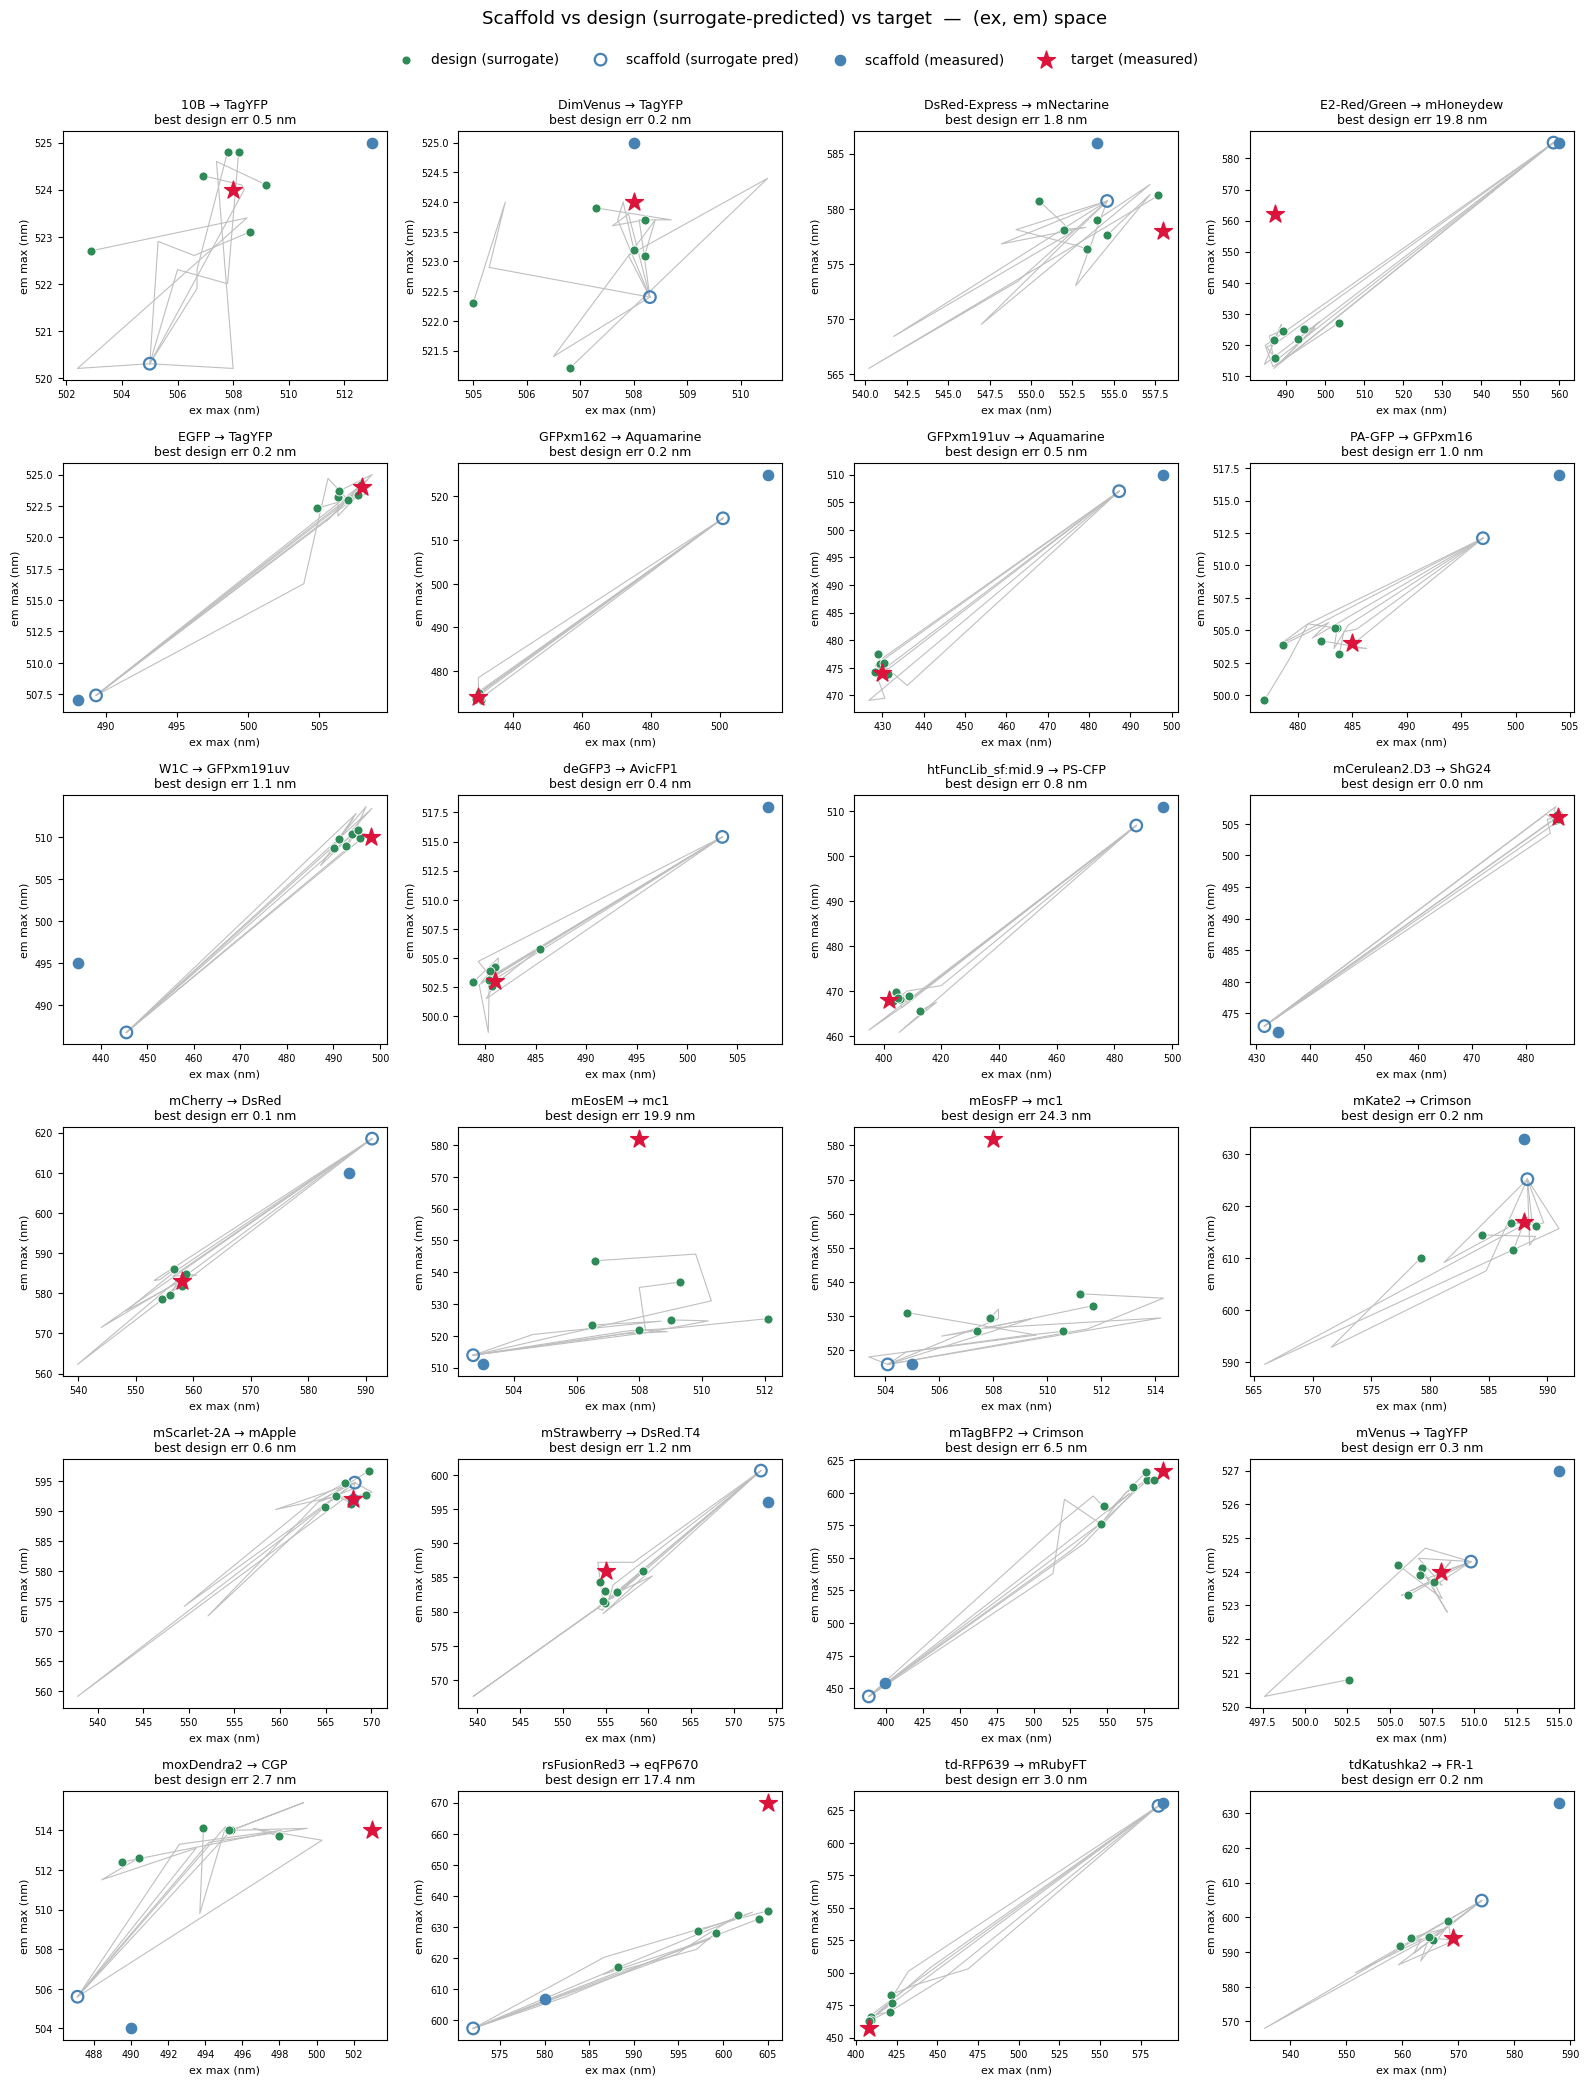

In [ ]:
ncol = 4
nrow = int(np.ceil(len(pairs) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4 * ncol, 3.4 * nrow))
axes = axes.ravel()

for ax, p in zip(axes, pairs):
    g = df[df["pair"] == p]
    sc_ex, sc_em = g["scaffold_ex"].iloc[0], g["scaffold_em"].iloc[0]
    tg_ex, tg_em = g["target_ex"].iloc[0], g["target_em"].iloc[0]
    # per-trial trajectory (rounds 0..RMAX) in surrogate-predicted space
    for _, gt in g.groupby("trial"):
        gt = gt.sort_values("round")
        ax.plot(gt["pred_ex"], gt["pred_em"], "-", color="0.75", lw=0.8, zorder=1)
    gf = g[g["round"] == RMAX]
    g0 = g[g["round"] == 0].iloc[0]
    ax.scatter(gf["pred_ex"], gf["pred_em"], s=42, c="seagreen", edgecolor="white",
               linewidth=0.6, zorder=3, label="design (surrogate)")
    ax.scatter([g0["pred_ex"]], [g0["pred_em"]], s=70, facecolor="none", edgecolor="steelblue",
               linewidth=1.6, zorder=2, label="scaffold (surrogate pred)")
    ax.scatter([sc_ex], [sc_em], s=55, c="steelblue", zorder=4, label="scaffold (measured)")
    ax.scatter([tg_ex], [tg_em], s=180, c="crimson", marker="*", zorder=5, label="target (measured)")
    best = g.loc[g["round"] == RMAX, "peak_err"].min()
    ax.set_title(f"{p}\nbest design err {best:.1f} nm", fontsize=9)
    ax.set_xlabel("ex max (nm)", fontsize=8); ax.set_ylabel("em max (nm)", fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[len(pairs):]:
    ax.axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=10, frameon=False,
           bbox_to_anchor=(0.5, 1.005))
fig.suptitle("Scaffold vs design (surrogate-predicted) vs target  —  (ex, em) space", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peaks_overview.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peaks_overview.png")
plt.show()

## Interactive explorer

Pick a pair from the dropdown to inspect its 6 design trajectories in `(ex, em)` space. Hover any
point for the exact peaks. Requires `plotly` (falls back to a message if unavailable).

In [ ]:
try:
    import plotly.graph_objects as go
    fig = go.Figure()
    trace_pair = []  # which pair each trace belongs to (for the dropdown)

    def add(pair_i, **kw):
        fig.add_trace(go.Scatter(visible=(pair_i == 0), **kw)); trace_pair.append(pair_i)

    for pi, p in enumerate(pairs):
        g = df[df["pair"] == p]
        sc_ex, sc_em = g["scaffold_ex"].iloc[0], g["scaffold_em"].iloc[0]
        tg_ex, tg_em = g["target_ex"].iloc[0], g["target_em"].iloc[0]
        xs, ys = [], []
        for _, gt in g.groupby("trial"):
            gt = gt.sort_values("round")
            xs += list(gt["pred_ex"]) + [None]; ys += list(gt["pred_em"]) + [None]
        add(pi, x=xs, y=ys, mode="lines", line=dict(color="lightgray", width=1),
            name="trajectory", showlegend=(pi == 0), hoverinfo="skip")
        gf = g[g["round"] == RMAX]
        add(pi, x=gf["pred_ex"], y=gf["pred_em"], mode="markers",
            marker=dict(color="seagreen", size=10, line=dict(width=1, color="white")),
            name="design (surrogate)", showlegend=(pi == 0),
            text=[f"trial {int(t)}, err {e:.1f} nm" for t, e in zip(gf["trial"], gf["peak_err"])],
            hovertemplate="design: ex %{x:.0f}, em %{y:.0f}<br>%{text}<extra></extra>")
        g0 = g[g["round"] == 0].iloc[0]
        add(pi, x=[g0["pred_ex"]], y=[g0["pred_em"]], mode="markers",
            marker=dict(symbol="circle-open", color="steelblue", size=13, line=dict(width=2)),
            name="scaffold (surrogate pred)", showlegend=(pi == 0),
            hovertemplate="scaffold pred: ex %{x:.0f}, em %{y:.0f}<extra></extra>")
        add(pi, x=[sc_ex], y=[sc_em], mode="markers",
            marker=dict(symbol="circle", color="steelblue", size=13),
            name="scaffold (measured)", showlegend=(pi == 0),
            hovertemplate="scaffold measured: ex %{x:.0f}, em %{y:.0f}<extra></extra>")
        add(pi, x=[tg_ex], y=[tg_em], mode="markers",
            marker=dict(symbol="star", color="crimson", size=17),
            name="target (measured)", showlegend=(pi == 0),
            hovertemplate="target measured: ex %{x:.0f}, em %{y:.0f}<extra></extra>")

    tp = np.array(trace_pair)
    buttons = [dict(label=p, method="update",
                    args=[{"visible": list(tp == pi)},
                          {"title": f"{p}   —   (ex, em) space (design = surrogate-predicted)"}])
               for pi, p in enumerate(pairs)]
    fig.update_layout(
        updatemenus=[dict(buttons=buttons, x=1.02, y=1.0, xanchor="left", showactive=True)],
        title=f"{pairs[0]}   —   (ex, em) space (design = surrogate-predicted)",
        xaxis_title="excitation max (nm)", yaxis_title="emission max (nm)",
        width=860, height=580, legend=dict(orientation="h", y=-0.16))
    fig.show()
except ModuleNotFoundError:
    print("plotly not installed — see the static overview above (pip install plotly to enable this).")

## Per-pair design error (surrogate)

How far the designs land from the target under the surrogate: the scaffold's starting error vs the
mean and best over the 6 trials, each taken at **its best round** (the round ≥ 1 minimizing surrogate
peak error — round 0 is the untouched scaffold and is excluded, so a "best design" is always an actual
edited sequence, never the scaffold), per pair (sorted by best). Again, these are the surrogate's own
predictions of designs it optimized — read as the design *objective*, not validation.

saved figures/campaign_design_error.png


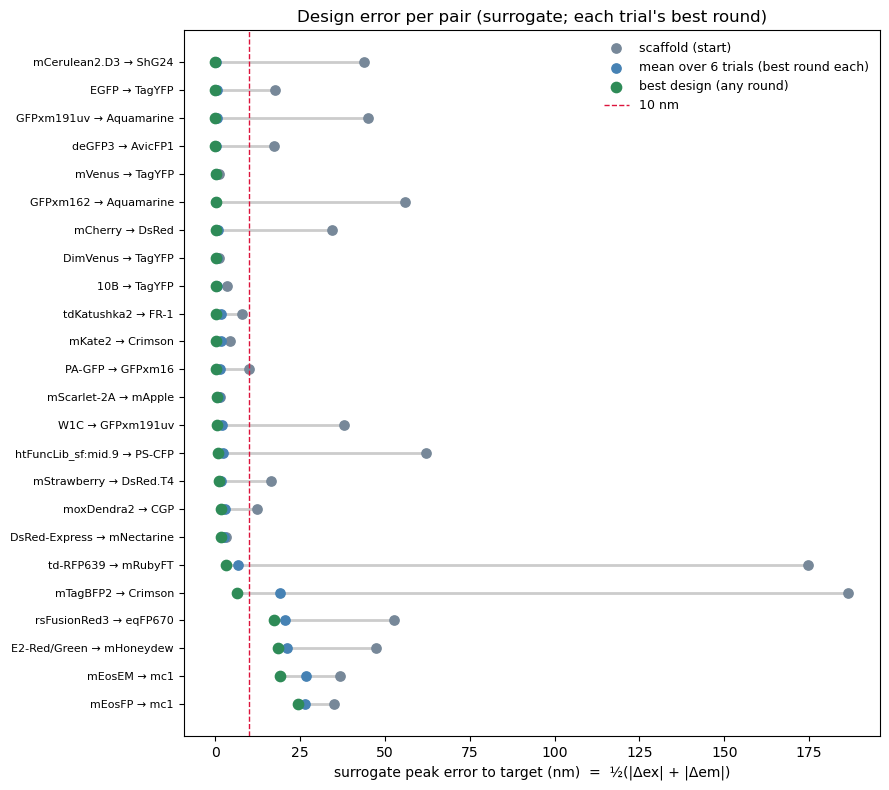

In [ ]:
s = summary.sort_values("best_design").reset_index(drop=True)
y = np.arange(len(s))
fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(y, s["best_design"], s["scaffold_err"], color="0.8", lw=2, zorder=1)
n_trials = df.trial.nunique()
ax.scatter(s["scaffold_err"], y, s=45, c="lightslategray", label="scaffold (start)", zorder=2)
ax.scatter(s["mean_design"], y, s=45, c="steelblue", label=f"mean over {n_trials} trials (best round each)", zorder=3)
ax.scatter(s["best_design"], y, s=55, c="seagreen", label="best design (any round)", zorder=4)
ax.axvline(10, ls="--", color="crimson", lw=1, label="10 nm")
ax.set_yticks(y); ax.set_yticklabels(s["pair"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("Design error per pair (surrogate; each trial's best round)")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_design_error.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_design_error.png")
plt.show()

## Gibbs-sampling designs

Load the Gibbs-sampling campaign (`gibbs-sampling/designs/design_*.csv`) for comparison with the
greedy guided-generation run above. Same surrogate-predicted `(ex, em)`, same target-distance
metric; the Gibbs run draws more candidates per pair.

In [5]:
_gcands = [Path("gibbs-sampling/designs"),
           Path("design-campaign-conventional/gibbs-sampling/designs"),
           Path.cwd() / "gibbs-sampling" / "designs"]
GIBBS = next((c for c in _gcands if c.exists()), None)
assert GIBBS is not None, "could not find gibbs-sampling/designs"

dfg = load_designs(GIBBS)
RMAX_G = int(dfg["round"].max())
summary_g = pair_summary(dfg)
print(f"gibbs: {dfg['pair'].nunique()} pairs, {len(dfg)} rows | rounds 0..{RMAX_G} | "
      f"trials {dfg.trial.nunique()}")
print(f"[each trial's best round] improved best over scaffold: {(summary_g.best_design < summary_g.scaffold_err).sum()}"
      f"/{len(summary_g)} | best within 10 nm: {(summary_g.best_design < 10).sum()}/{len(summary_g)}")
summary_g.round(1)

gibbs: 24 pairs, 2304 rows | rounds 0..3 | trials 24
[each trial's best round] improved best over scaffold: 15/24 | best within 10 nm: 7/24


,pair,scaffold_err,mean_design,best_design
0,mCerulean2.D3 → ShG24,43.8,7.9,0.7
1,deGFP3 → AvicFP1,17.4,14.2,1.4
2,GFPxm162 → Aquamarine,55.9,12.6,2.0
3,PA-GFP → GFPxm16,10.0,10.3,2.2
4,GFPxm191uv → Aquamarine,45.2,13.5,2.6
5,W1C → GFPxm191uv,37.9,21.5,4.8
6,moxDendra2 → CGP,12.2,14.4,7.6
7,EGFP → TagYFP,17.7,31.5,10.3
8,10B → TagYFP,3.3,31.9,11.2
9,mVenus → TagYFP,1.0,28.2,13.0


### Per-pair design error — Gibbs sampling

Same lollipop as the guided run: scaffold's starting error → mean and best over the Gibbs trials,
each taken at **its best round** (round ≥ 1, i.e. an actual edited design, excluding the scaffold),
per pair (surrogate-predicted, sorted by best). In-sample/optimistic (surrogate scoring its own
designs). Note many Gibbs trials never beat the scaffold — their best *design* is still recorded so
these bars reflect genuine edits, not the original sequence.

saved figures/campaign_design_error_gibbs.png


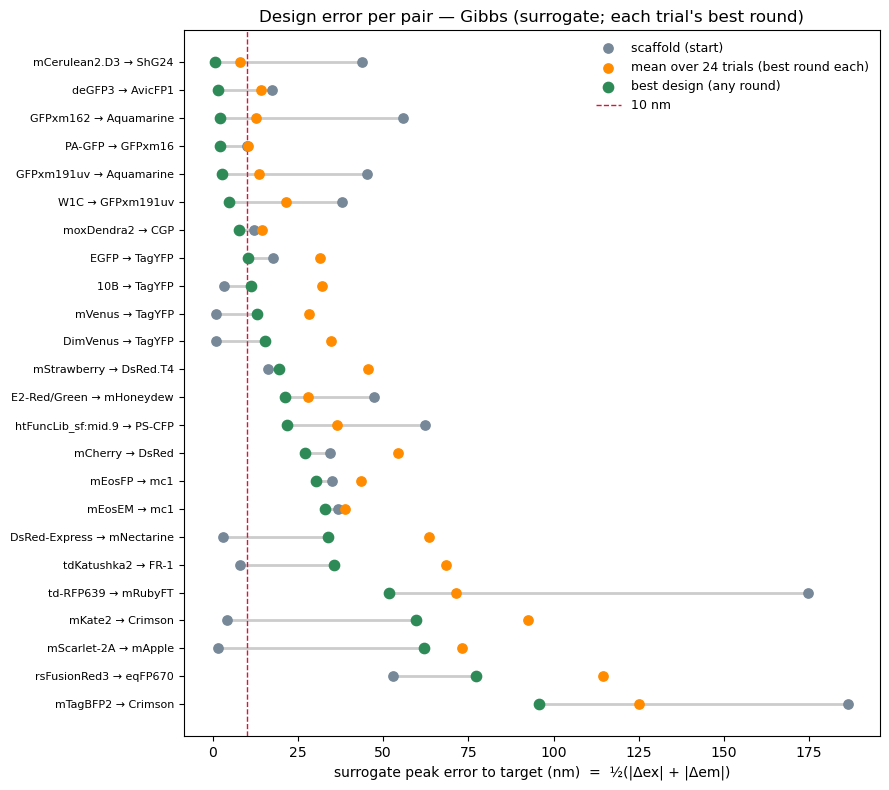

In [6]:
n_trials_g = dfg.trial.nunique()
s = summary_g.sort_values("best_design").reset_index(drop=True)
y = np.arange(len(s))
fig, ax = plt.subplots(figsize=(9, 8))
ax.hlines(y, s["best_design"], s["scaffold_err"], color="0.8", lw=2, zorder=1)
ax.scatter(s["scaffold_err"], y, s=45, c="lightslategray", label="scaffold (start)", zorder=2)
ax.scatter(s["mean_design"], y, s=45, c="darkorange", label=f"mean over {n_trials_g} trials (best round each)", zorder=3)
ax.scatter(s["best_design"], y, s=55, c="seagreen", label="best design (any round)", zorder=4)
ax.axvline(10, ls="--", color="crimson", lw=1, label="10 nm")
ax.set_yticks(y); ax.set_yticklabels(s["pair"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("Design error per pair — Gibbs (surrogate; each trial's best round)")
ax.legend(fontsize=9, frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_design_error_gibbs.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_design_error_gibbs.png")
plt.show()

## Guided vs Gibbs — per-peak distance to target

Distance of **each individual design** from its target, with the **excitation** and **emission**
peaks separated: `|Δex| = |pred_ex − target_ex|` and `|Δem| = |pred_em − target_em|`
(surrogate-predicted). Each point is one design attempt taken at **its best round** (the round ≥ 1 that
minimizes surrogate peak error — the scaffold at round 0 is excluded, so every point is a real edit).
The black bar marks the median.
Guided draws 6 attempts/pair, Gibbs 24/pair, so the Gibbs strip has more points and shows its wider
exploration.

saved figures/campaign_peak_distance_strip.png

peak        method      n   median    mean     p90
Excitation  guided    144      0.9     2.6     5.3
Excitation  gibbs     576     35.5    43.8    91.2
Emission    guided    144      0.9     9.2    41.2
Emission    gibbs     576     35.2    45.8    96.1


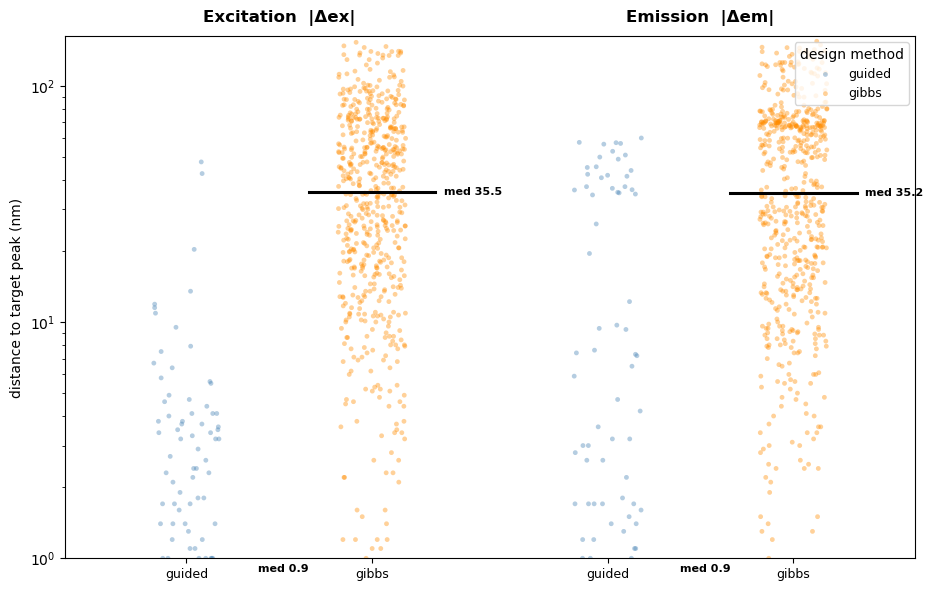

In [7]:
methods = [("guided", df, "steelblue"), ("gibbs", dfg, "darkorange")]
peaks = [("Excitation  |\u0394ex|", "pred_ex", "target_ex"),
         ("Emission  |\u0394em|", "pred_em", "target_em")]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(9.5, 6))
tick_x, tick_lab = [], []
stats = []
for pk_i, (pk_label, pcol, tcol) in enumerate(peaks):
    for m_i, (mname, d, color) in enumerate(methods):
        fin = best_per_trial(d)   # each trial's best round (min surrogate peak_err)
        dist = (fin[pcol] - fin[tcol]).abs().to_numpy()
        cx = pk_i + (-0.22 if m_i == 0 else 0.22)
        x = cx + rng.uniform(-0.08, 0.08, size=len(dist))
        ax.scatter(x, dist, s=12, c=color, alpha=0.4, edgecolor="none",
                   label=mname if pk_i == 0 else None, zorder=2)
        med = float(np.median(dist))
        ax.plot([cx - 0.15, cx + 0.15], [med, med], color="black", lw=2.2, zorder=5)
        ax.text(cx + 0.17, med, f"med {med:.1f}", ha="left", va="center", fontsize=8,
                fontweight="bold", zorder=6)
        tick_x.append(cx); tick_lab.append(mname)
        stats.append((pk_label.split()[0], mname, len(dist), med,
                      float(np.mean(dist)), float(np.percentile(dist, 90))))

ax.set_xticks(tick_x); ax.set_xticklabels(tick_lab, fontsize=9)
for pk_i, (pk_label, _, _) in enumerate(peaks):
    ax.text(pk_i, 1.02, pk_label, ha="center", va="bottom", fontsize=12,
            fontweight="bold", transform=ax.get_xaxis_transform())
ax.axhline(0, color="0.6", lw=0.8)
ax.set_ylabel("distance to target peak (nm)")
ax.set_ylim(bottom=1)
ax.set_yscale("log")
ax.legend(title="design method", fontsize=9, loc="upper right", frameon=True)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peak_distance_strip.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peak_distance_strip.png\n")
print(f"{'peak':12}{'method':8}{'n':>5}{'median':>9}{'mean':>8}{'p90':>8}")
for pk, mn, n, md, me, p9 in stats:
    print(f"{pk:12}{mn:8}{n:>5}{md:>9.1f}{me:>8.1f}{p9:>8.1f}")
plt.show()

## Convergence — surrogate MAE vs iteration round

For each method, plot the surrogate MAE to target (`½(|Δex| + |Δem|)` = `peak_err`) against the
iteration round. At every round a single **unfilled boxplot** (`facecolor='none'`) summarizes the
distribution pooled across **all** shown designs; a **connected median** line and a **connected
minimum** line track the round-over-round trend. Every **design attempt** (one trial's trajectory) is
also overlaid faintly in its **pair's color** (round 0 is the shared scaffold starting point).

Tune `N_PAIRS_SHOW` / `N_TRIALS_SHOW` below to control which designs are pooled and overlaid.

saved figures/campaign_convergence_guided.png


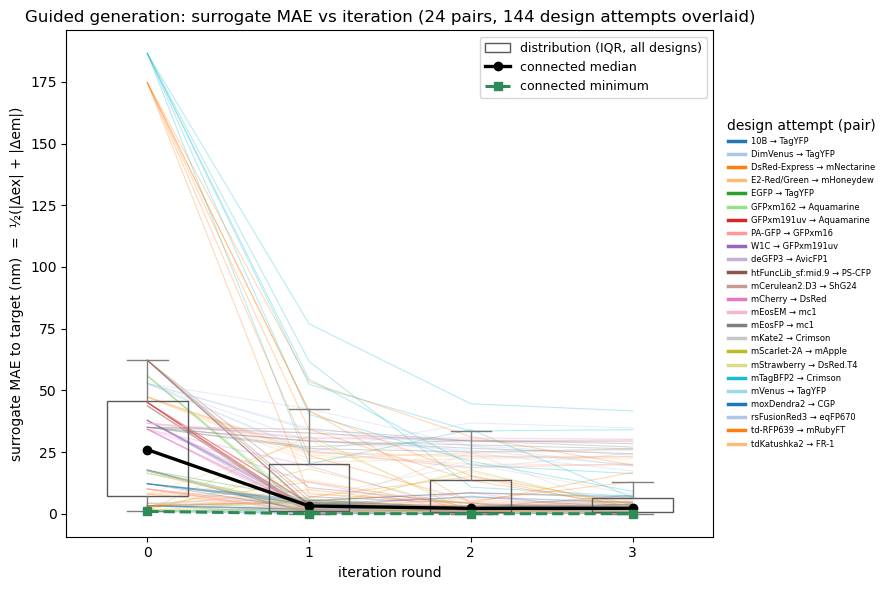

saved figures/campaign_convergence_gibbs.png


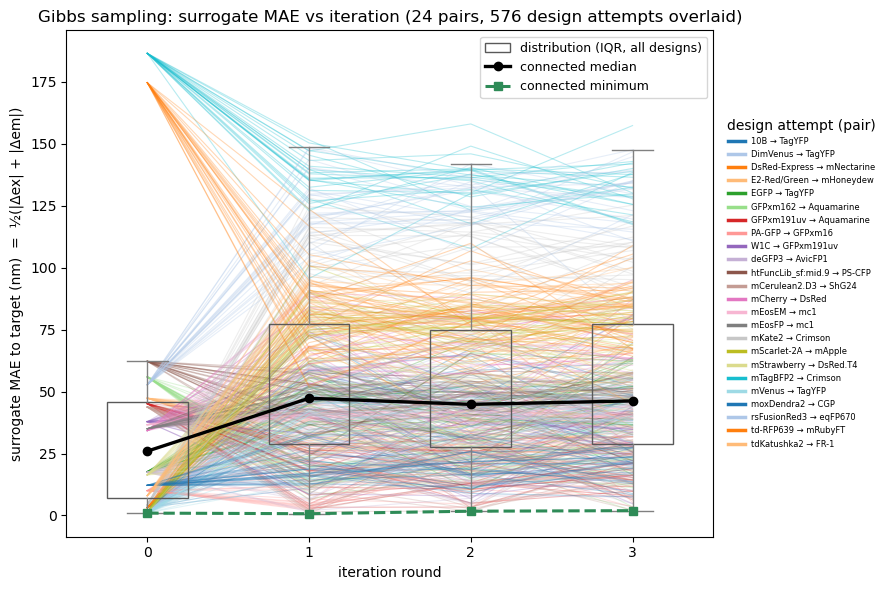

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- tune which designs go into the aggregate distribution ------------------------
N_PAIRS_SHOW = 24        # number of scaffold->target pairs pooled into the boxplots
N_TRIALS_SHOW = None     # trials per pair pooled; None = all trials
# ----------------------------------------------------------------------------------


def plot_convergence(d, method_name, fname, n_pairs=N_PAIRS_SHOW, n_trials=N_TRIALS_SHOW):
    rmax = int(d["round"].max())
    rounds = list(range(rmax + 1))
    ps = d.groupby("pair")["scaffold_idx"].first().index.tolist()[:n_pairs]

    cmap = plt.get_cmap("tab20")
    pair_color = {p: cmap(i % 20) for i, p in enumerate(ps)}

    sub = d[d["pair"].isin(ps)].copy()
    if n_trials is not None:
        sub = sub[sub["trial"] < n_trials]

    # one aggregate distribution per round, pooled across ALL shown designs
    box_data = [sub.loc[sub["round"] == r, "peak_err"].to_numpy() for r in rounds]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(box_data, positions=rounds, widths=0.5, showfliers=False, patch_artist=True,
               zorder=4, boxprops=dict(facecolor="none", edgecolor="0.35"),
               medianprops=dict(color="none"), whiskerprops=dict(color="0.5"),
               capprops=dict(color="0.5"))

    # overlay each individual design attempt (one trial's trajectory), colored by pair
    n_shown = 0
    for p in ps:
        for tr, gt in sub[sub["pair"] == p].groupby("trial"):
            gt = gt.sort_values("round")
            ax.plot(gt["round"], gt["peak_err"], "-", color=pair_color[p],
                    alpha=0.3, lw=0.8, zorder=2)
            n_shown += 1

    # connected median and connected minimum across rounds (over all pooled designs)
    meds = [float(np.median(b)) for b in box_data]
    mins = [float(np.min(b)) for b in box_data]
    ax.plot(rounds, meds, "-o", color="black", lw=2.4, ms=6, zorder=6)
    ax.plot(rounds, mins, "--s", color="seagreen", lw=2.2, ms=6, zorder=6)

    ax.set_xticks(rounds); ax.set_xlim(-0.5, rmax + 0.5)
    ax.set_xlabel("iteration round")
    ax.set_ylabel("surrogate MAE to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
    ax.set_title(f"{method_name}: surrogate MAE vs iteration "
                 f"({len(ps)} pairs, {n_shown} design attempts overlaid)")

    style_leg = ax.legend([Patch(facecolor="none", edgecolor="0.35"),
                           Line2D([0], [0], color="black", lw=2.4, marker="o"),
                           Line2D([0], [0], color="seagreen", lw=2.2, ls="--", marker="s")],
                          ["distribution (IQR, all designs)", "connected median", "connected minimum"],
                          loc="upper right", fontsize=9, frameon=True)
    ax.add_artist(style_leg)
    ax.legend([Line2D([0], [0], color=pair_color[p], lw=2.5) for p in ps], ps,
              fontsize=6, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, title="design attempt (pair)")
    fig.tight_layout()
    fig.savefig(FIGDIR / fname, dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / fname)
    plt.show()


plot_convergence(df, "Guided generation", "campaign_convergence_guided.png")
plot_convergence(dfg, "Gibbs sampling", "campaign_convergence_gibbs.png")